# Real Estate Price Prediction

> **Scenario:** A new real estate company lets homeowners sell online at a small discount from estimated value, then resells at a higher price. 
The model must **accurately predict selling price** — overpay = loss, underpay = no deal.  
> **Competitive Advantage:** Proprietary database of public + private housing data and historical transactions.  
> **Objective:** Build an ML model to set the buy price the company offers homeowners.

---

## 1 · Define the Problem

- **Goal:** Predict house selling price → company offers `predicted_price × (1 − discount_rate)` to homeowners  
- **Primary KPI:** RMSE — large errors = direct financial loss  
- **Secondary KPIs:** MAE, R², % of predictions within ±10 % of actual  
- **Over-prediction risk:** Company pays too much, resells at a loss  
- **Under-prediction risk:** Homeowners reject the offer (lost volume)  
- **Why ML:** Captures non-linear relationships that traditional comps-based appraisals miss

---
## 2 · Data Collection & Cleaning

Load the proprietary dataset (public + private housing data), then clean:
- Rename columns for clarity (snake_case)
- Check for missing values
- Apply data transformations:
  - Unit normalization to mitigate outliers
  - Log transformation to reduce skewness in price and features  
- Detect and address outliers (IQR)

#### 2.1 · Imports

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Add project root to sys.path for module imports
# -----------------------------
root = "/Users/phillipsmith/Desktop/pythonProjects/real-estate-price-prediction"
sys.path.append(root)

# -----------------------------
# Import external python modules
# -----------------------------
from pathlib import Path

from src.preprocessing import data_preparation, data_transformation
from src.viz import plotting

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from math import sqrt

#### 2.2 · Configuration & Data Loading

In [19]:
# -----------------------------
# Display full dataframes
# -----------------------------
pd.set_option('display.max_rows', None) # reset_option to compact dataframe view
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

# -----------------------------
# Define path to raw Excel data source
# -----------------------------
excel_path = Path(
    '/Users/phillipsmith/Desktop/pythonProjects/real-estate-price-prediction/src/data/raw/Dataset Project 2.xlsx'
)

# -----------------------------
# Read raw data from Excel source
# -----------------------------
df_raw = pd.read_excel(excel_path, skiprows=1)
print(f"Raw DataFrame shape: {df_raw.shape}")

df_raw.head()

Raw DataFrame shape: (506, 15)


,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,popul,lstat,price
0,1,0.006320,18.000000,2.310000,0,0.538000,6.575000,65.200000,4.090000,1,296,15.300000,396.900000,4.980000,24.000000
1,2,0.027310,0.000000,7.070000,0,0.469000,6.421000,78.900000,4.967100,2,242,17.800000,396.900000,9.140000,21.600000
2,3,0.027290,0.000000,7.070000,0,0.469000,7.185000,61.100000,4.967100,2,242,17.800000,392.830000,4.030000,34.700000
3,4,0.032370,0.000000,2.180000,0,0.458000,6.998000,45.800000,6.062200,3,222,18.700000,394.630000,2.940000,33.400000
4,5,0.069050,0.000000,2.180000,0,0.458000,7.147000,54.200000,6.062200,3,222,18.700000,396.900000,5.330000,36.200000


#### 2.3 · Data Cleaning

Column headers are not standardized, so I need to rename them for clarity.

In [3]:
df_cleaned = data_preparation.clean_data(df_raw)

# statistical summary
df_cleaned.describe()

,crime_rate_per_capita_crim,large_lot_zoning_ratio_zn,non_retail_acre_ratio_indus,river_boundary_flag_chas,nox_concentration_nox,avg_rooms_per_dwelling_rm,pre_1940_housing_ratio_age,employment_center_distance_dis,radial_highway_access_idx_rad,property_tax_rate_tax,pupil_teacher_ratio_ptratio,population_distribution_popul,low_ses_population_pct_lstat,price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


#### 2.4 · Missing Values
Check for nulls. Apply imputation as needed (mean/median for numeric, mode for categorical).

In [4]:
print(df_cleaned[df_cleaned.columns].isna().sum()) # None

crime_rate_per_capita_crim        0
large_lot_zoning_ratio_zn         0
non_retail_acre_ratio_indus       0
river_boundary_flag_chas          0
nox_concentration_nox             0
avg_rooms_per_dwelling_rm         0
pre_1940_housing_ratio_age        0
employment_center_distance_dis    0
radial_highway_access_idx_rad     0
property_tax_rate_tax             0
pupil_teacher_ratio_ptratio       0
population_distribution_popul     0
low_ses_population_pct_lstat      0
price                             0
dtype: int64


No missing values found in the dataframe.

#### 2.5 · Data Transformations

Apply unit normalization, log transforms, outlier detection, and one hot encoding to numeric features to account for outliers, reduce skewness, and improve feature quality of independent and dependent variables.

In [5]:
df_transformed = data_transformation.transform_data(df_cleaned.copy())
df_transformed.head()

,crime_rate_per_capita_crim,large_lot_zoning_ratio_zn,non_retail_acre_ratio_indus,river_boundary_flag_chas,nox_concentration_nox,avg_rooms_per_dwelling_rm,pre_1940_housing_ratio_age,employment_center_distance_dis,property_tax_rate_tax,pupil_teacher_ratio_ptratio,population_distribution_popul,low_ses_population_pct_lstat,price,rad_1,rad_2,rad_3,rad_4,rad_5,rad_6,rad_7,rad_8,rad_24,pre_1940_housing_ratio_age_flip,pupil_teacher_ratio_ptratio_flip,population_distribution_popul_flip,crime_rate_per_capita_crim_log,large_lot_zoning_ratio_zn_log,non_retail_acre_ratio_indus_log,nox_concentration_nox_log,pre_1940_housing_ratio_age_flip_log,employment_center_distance_dis_log,property_tax_rate_tax_log,pupil_teacher_ratio_ptratio_flip_log,population_distribution_popul_flip_log,low_ses_population_pct_lstat_log,crime_rate_per_capita_crim_log_outlier,large_lot_zoning_ratio_zn_log_outlier,low_ses_population_pct_lstat_log_outlier,price_outlier
0,0.006320,0.180000,0.023100,0,0.538000,6.575000,0.652000,4.090000,0.029600,15.300000,396.900000,0.049800,240000.000000,1,0,0,0,0,0,0,0,0,1.348000,7.700000,1.000000,0.006300,0.165514,0.022837,0.430483,0.853564,1.627278,0.029170,2.163323,0.693147,0.048600,0,0,0,0
1,0.027310,0.000000,0.070700,0,0.469000,6.421000,0.789000,4.967100,0.024200,17.800000,396.900000,0.091400,216000.000000,0,1,0,0,0,0,0,0,0,1.211000,5.200000,1.000000,0.026944,0.000000,0.068313,0.384582,0.793445,1.786261,0.023912,1.824549,0.693147,0.087461,0,0,0,0
2,0.027290,0.000000,0.070700,0,0.469000,7.185000,0.611000,4.967100,0.024200,17.800000,392.830000,0.040300,347000.000000,0,1,0,0,0,0,0,0,0,1.389000,5.200000,5.070000,0.026924,0.000000,0.068313,0.384582,0.870875,1.786261,0.023912,1.824549,1.803359,0.039509,0,0,0,0
3,0.032370,0.000000,0.021800,0,0.458000,6.998000,0.458000,6.062200,0.022200,18.700000,394.630000,0.029400,334000.000000,0,0,1,0,0,0,0,0,0,1.542000,4.300000,3.270000,0.031857,0.000000,0.021566,0.377066,0.932951,1.954757,0.021957,1.667707,1.451614,0.028976,0,0,0,0
4,0.069050,0.000000,0.021800,0,0.458000,7.147000,0.542000,6.062200,0.022200,18.700000,396.900000,0.053300,362000.000000,0,0,1,0,0,0,0,0,0,1.458000,4.300000,1.000000,0.066770,0.000000,0.021566,0.377066,0.899348,1.954757,0.021957,1.667707,0.693147,0.051928,0,0,0,0


---
## 3 · Exploratory Data Analysis (EDA)

#### 3.1 · Raw Variable Distributions

<Axes: title={'center': 'price_log'}, xlabel='price_log', ylabel='Count'>

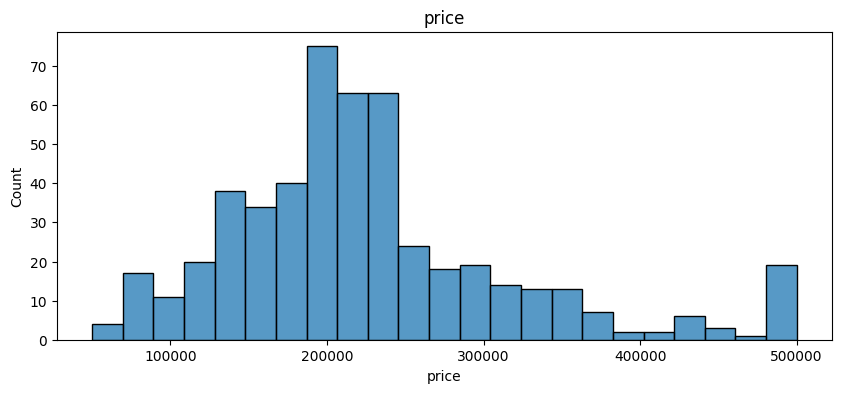

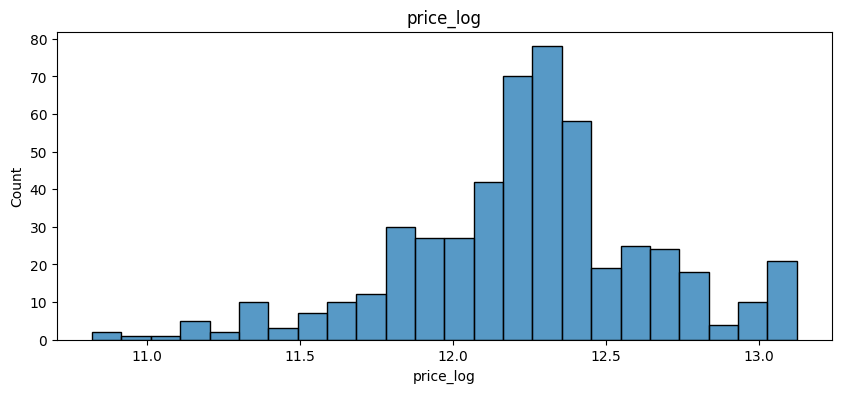

In [6]:
"""RAW DISTRIBUTION PLOTS"""
var_raw = 'price'
var_log = var_raw + "_log"

# normal histplot
fig, ax = plt.subplots(figsize=(10,4))
plt.title(var_raw)
sns.histplot(df_transformed[var_raw], bins='auto', ax=ax)

# log transformed histplot
df_transformed[var_log] = np.log1p(df_transformed[var_raw])
fig, ax = plt.subplots(figsize=(10,4))
plt.title(var_log)
sns.histplot(df_transformed[var_log], bins='auto', ax=ax)

#### 3.2 · Generate EDA Plots
- Generate histograms, count plots, and a correlation matrix for numeric features (more info on bin parameters: 
(https://numpy.org/doc/stable/reference/generated/numpy.histogram_bin_edges.html#numpy.histogram_bin_edges)
- Look for skewness → candidates for log and Box-Cox transforms
    - bins='fd' (Freedman-Diaconis) is often good for skewed data
- Plots are exported to (`docs`) directory for review.

In [7]:
"""HISTOGRAMS, COUNT PLOTS, CORRELATION MATRIX"""

df_correlated = plotting.explore_data(df_transformed)
df_correlated.head()

,river_boundary_flag_chas,avg_rooms_per_dwelling_rm,price,rad_1,rad_2,rad_3,rad_4,rad_5,rad_6,rad_7,rad_8,rad_24,crime_rate_per_capita_crim_log,large_lot_zoning_ratio_zn_log,non_retail_acre_ratio_indus_log,nox_concentration_nox_log,pre_1940_housing_ratio_age_flip_log,employment_center_distance_dis_log,property_tax_rate_tax_log,pupil_teacher_ratio_ptratio_flip_log,population_distribution_popul_flip_log,low_ses_population_pct_lstat_log,crime_rate_per_capita_crim_log_outlier,large_lot_zoning_ratio_zn_log_outlier,low_ses_population_pct_lstat_log_outlier
0,0,6.575000,240000.000000,1,0,0,0,0,0,0,0,0,0.006300,0.165514,0.022837,0.430483,0.853564,1.627278,0.029170,2.163323,0.693147,0.048600,0,0,0
1,0,6.421000,216000.000000,0,1,0,0,0,0,0,0,0,0.026944,0.000000,0.068313,0.384582,0.793445,1.786261,0.023912,1.824549,0.693147,0.087461,0,0,0
2,0,7.185000,347000.000000,0,1,0,0,0,0,0,0,0,0.026924,0.000000,0.068313,0.384582,0.870875,1.786261,0.023912,1.824549,1.803359,0.039509,0,0,0
3,0,6.998000,334000.000000,0,0,1,0,0,0,0,0,0,0.031857,0.000000,0.021566,0.377066,0.932951,1.954757,0.021957,1.667707,1.451614,0.028976,0,0,0
4,0,7.147000,362000.000000,0,0,1,0,0,0,0,0,0,0.066770,0.000000,0.021566,0.377066,0.899348,1.954757,0.021957,1.667707,0.693147,0.051928,0,0,0


While correlation is a useful first-pass filter, I will also consider feature selection methods to capture non-linear relationships between features that correlation may miss.

---
## 4 · Feature Engineering

- Determine importance of features by applying feature selection methods
- Use error metrics (RMSE) to evaluate feature subsets and select the optimal set for modeling

#### 4.0 · Baseline Error Check

In [8]:
X = pd.DataFrame(df_correlated.drop(columns=['price']))
y = df_correlated['price']

# splits data into equal-sized subsets
cv = KFold(n_splits=10, random_state=0, shuffle=True)
classifier_pipeline = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10))

y_pred = cross_val_predict(classifier_pipeline, X, y, cv=cv)
print("RMSE: " + str(round(sqrt(mean_squared_error(y,y_pred)),2)))
print("R_squared: " + str(round(r2_score(y,y_pred),2)))

RMSE: 54182.24
R_squared: 0.65


A baseline RMSE of $54,182.24 has been established using explanatory features in df_correlated with a KNN regressor (k=10) and 10-fold cross-validation.

R_squared is 0.65, indicating that the model explains 65% of the variance in the target variable. I will attempt to increase this coverage by implementing feature selection methods to identify the most relevant features for predicting house prices.

#### 4.1 · Feature Selection Using a Wrapper

Sequential Forward Selection (SFS) is a wrapper method that iteratively adds features to the model based on performance improvement. It evaluates the model's performance (using RMSE) after adding each feature and selects the one that provides the best improvement. This process continues until the specified number of features (k_features=15) is reached.

In [9]:
sfs1 = SFS(classifier_pipeline,
           k_features=9,
           forward=True,
           scoring='neg_mean_squared_error',
           cv=cv)

X = df_correlated.drop(columns=['price'])

sfs1.fit(X, y)
sfs1.subsets_

{1: {'feature_idx': (20,),
  'cv_scores': array([-3.52451137e+09, -3.47380196e+09, -2.01319843e+09, -3.35886039e+09,
         -2.07381000e+09, -2.06953353e+09, -2.65054700e+09, -3.00333820e+09,
         -4.95259440e+09, -2.08770520e+09]),
  'avg_score': np.float64(-2920790048.627451),
  'feature_names': ('low_ses_population_pct_lstat_log',)},
 2: {'feature_idx': (1, 20),
  'cv_scores': array([-4.05665392e+09, -1.71361176e+09, -1.70123020e+09, -9.63284902e+08,
         -2.34744431e+09, -1.21632098e+09, -1.74844560e+09, -4.12154500e+09,
         -1.81385760e+09, -9.09268600e+08]),
  'avg_score': np.float64(-2059166287.8431373),
  'feature_names': ('avg_rooms_per_dwelling_rm',
   'low_ses_population_pct_lstat_log')},
 3: {'feature_idx': (1, 14, 20),
  'cv_scores': array([-3.86138451e+09, -1.60096020e+09, -8.88938431e+08, -6.48814118e+08,
         -2.49854137e+09, -9.27822745e+08, -1.19992220e+09, -3.24230040e+09,
         -1.26591520e+09, -8.57894800e+08]),
  'avg_score': np.float64(-1699

In [20]:
# select features from SFS output
X = df_correlated.drop(columns=['price'])[[
'avg_rooms_per_dwelling_rm',
   'rad_24',
   'crime_rate_per_capita_crim_log',
   'nox_concentration_nox_log',
   'employment_center_distance_dis_log',
   'property_tax_rate_tax_log',
   'pupil_teacher_ratio_ptratio_flip_log',
   'population_distribution_popul_flip_log',
   'low_ses_population_pct_lstat_log'
]]

y = df_correlated['price']

# RMSE and R^2
y_pred = cross_val_predict(classifier_pipeline, X, y, cv=cv)
print("RMSE: " + str(round(sqrt(mean_squared_error(y,y_pred)),2)))
print("R_squared: " + str(round(r2_score(y,y_pred),2)))

RMSE: 38264.09
R_squared: 0.83


OPTIMAL SFS RESULT: 

k=9, forward=True --> RMSE: 38264.09, R_squared: 0.83

By using SFS, I have minimized my RMSE to $38264.09 and maximized R_squared to 83% after several iterations. I will explore other feature selection methods to further optimize the model's performance.

#### 4.2 · Univariate: SelectKBest with f_regression

In [11]:
X = df_correlated.drop(columns=['price'])
y = df_correlated['price']
n_features = 9

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3)

"""METHOD 1: UNIVARIATE SELECTION"""
# Apply SelectKBest with chi2
select_k_best = SelectKBest(score_func=f_regression, k=n_features)
X_train_k_best = select_k_best.fit_transform(X_train, y_train)
print("SELECTED FEATURE (METHOD 1): \n", X_train.columns[select_k_best.get_support()])

SELECTED FEATURE (METHOD 1): 
 Index(['avg_rooms_per_dwelling_rm', 'crime_rate_per_capita_crim_log',
       'large_lot_zoning_ratio_zn_log', 'non_retail_acre_ratio_indus_log',
       'nox_concentration_nox_log', 'pre_1940_housing_ratio_age_flip_log',
       'property_tax_rate_tax_log', 'pupil_teacher_ratio_ptratio_flip_log',
       'low_ses_population_pct_lstat_log'],
      dtype='str')


In [12]:
# select features from SFS output
X = df_correlated.drop(columns=['price'])[[
'avg_rooms_per_dwelling_rm', 'crime_rate_per_capita_crim_log',
       'large_lot_zoning_ratio_zn_log', 'non_retail_acre_ratio_indus_log',
       'nox_concentration_nox_log', 'pre_1940_housing_ratio_age_flip_log',
       'property_tax_rate_tax_log', 'pupil_teacher_ratio_ptratio_flip_log',
       'low_ses_population_pct_lstat_log'
]]

y = df_correlated['price']

# RMSE and R^2
y_pred = cross_val_predict(classifier_pipeline, X, y, cv=cv)
print("RMSE: " + str(round(sqrt(mean_squared_error(y,y_pred)),2)))
print("R_squared: " + str(round(r2_score(y,y_pred),2)))

RMSE: 43363.78
R_squared: 0.78


Univariate feature selection using SelectKBest with f_regression appeared to be less optimal than SFS, yielding a higher RMSE of $43363.78 and a lower R_squared of 78% with its top 9 features.

#### 4.3 · Recursive Feature Elimination (RFE) with Linear Regression

In [13]:
"""METHOD 2: RECURSIVE FEATURE ELIMINATION"""
X = df_correlated.drop(columns=['price'])
y = df_correlated['price']
n_features = 5

# Apply RFE with logistic regression
linear_regression = LinearRegression()
rfe = RFE(linear_regression, n_features_to_select=n_features)
X_train_rfe = rfe.fit_transform(X_train, y_train)
print("\nSELECTED FEATURES (METHOD 2): \n", X_train.columns[rfe.get_support()])


SELECTED FEATURES (METHOD 2): 
 Index(['non_retail_acre_ratio_indus_log', 'nox_concentration_nox_log',
       'pre_1940_housing_ratio_age_flip_log',
       'low_ses_population_pct_lstat_log',
       'low_ses_population_pct_lstat_log_outlier'],
      dtype='str')


In [14]:
# select features from SFS output
X = df_correlated.drop(columns=['price'])[[
'non_retail_acre_ratio_indus_log', 'nox_concentration_nox_log',
       'pre_1940_housing_ratio_age_flip_log',
       'low_ses_population_pct_lstat_log',
       'low_ses_population_pct_lstat_log_outlier'
]]

y = df_correlated['price']

# RMSE and R^2
y_pred = cross_val_predict(classifier_pipeline, X, y, cv=cv)
print("RMSE: " + str(round(sqrt(mean_squared_error(y,y_pred)),2)))
print("R_squared: " + str(round(r2_score(y,y_pred),2)))

RMSE: 51713.21
R_squared: 0.68


Recursive Feature Elimination (RFE) with Linear Regression also underperformed compared to SFS and yielded worst results than the baseline error check with an RMSE of $54560.63 and an R_squared of 0.65 with its top 9 features. Reducing the number of features to 5 slightly improved its performance, but it is still not as good as SFS, with an RMSE of $51713.21 and an R_squared of 68%

#### 4.4 · Tree-Based Feature Importance

In [15]:
"""METHOD 3: TREE-BASED FEATURE IMPORTANCE"""
X = df_correlated.drop(columns=['price'])
y = df_correlated['price']
n_features = 9

# Train random forest and get feature importances
random_forest_regressor = RandomForestRegressor()
random_forest_regressor.fit(X_train, y_train)
importances = random_forest_regressor.feature_importances_

# Display feature importances
feature_importances = pd.Series(importances, index=X_train.columns)
print("\nSELECTED FEATURES (METHOD 3): \n", feature_importances.sort_values(ascending=False))


SELECTED FEATURES (METHOD 3): 
 low_ses_population_pct_lstat_log           0.457736
avg_rooms_per_dwelling_rm                  0.340448
employment_center_distance_dis_log         0.088961
crime_rate_per_capita_crim_log             0.044015
pre_1940_housing_ratio_age_flip_log        0.014059
nox_concentration_nox_log                  0.013736
property_tax_rate_tax_log                  0.011449
pupil_teacher_ratio_ptratio_flip_log       0.011426
population_distribution_popul_flip_log     0.008088
non_retail_acre_ratio_indus_log            0.004903
river_boundary_flag_chas                   0.001075
rad_1                                      0.000731
rad_4                                      0.000650
large_lot_zoning_ratio_zn_log              0.000604
rad_5                                      0.000533
rad_3                                      0.000433
rad_24                                     0.000311
rad_2                                      0.000255
rad_8                          

In [16]:
# select features from SFS output
X = df_correlated.drop(columns=['price'])[[
    'low_ses_population_pct_lstat_log',
    'avg_rooms_per_dwelling_rm',
    'employment_center_distance_dis_log',
    'crime_rate_per_capita_crim_log',
    'pre_1940_housing_ratio_age_flip_log',
    'property_tax_rate_tax_log',
    'pupil_teacher_ratio_ptratio_flip_log',
    'nox_concentration_nox_log',
    'population_distribution_popul_flip_log'
]]

y = df_correlated['price']

# RMSE and R^2
y_pred = cross_val_predict(classifier_pipeline, X, y, cv=cv)
print("RMSE: " + str(round(sqrt(mean_squared_error(y,y_pred)),2)))
print("R_squared: " + str(round(r2_score(y,y_pred),2)))

RMSE: 39601.73
R_squared: 0.81


Tree-based feature importance using a Random Forest Regressor provided better results than RFE and SelectKBest, but still did not outperform SFS. With the top 9 features, it achieved an RMSE of $39601.73 and an R_squared of 81%. It has proven to be a solid model for feature selection, but SFS still provides the best performance for this dataset.

#### 4.5 DataFrame Modeling
Selected independent variables (X) and a dependent variable (y = `price`). 

Display summary statistics for the final feature set.

In [17]:
modeling_df = df_correlated[[
    'avg_rooms_per_dwelling_rm',
    'rad_3',
    'rad_6',
    'crime_rate_per_capita_crim_log',
    'nox_concentration_nox_log',
    'pre_1940_housing_ratio_age_flip_log',
    'employment_center_distance_dis_log',
    'population_distribution_popul_flip_log',
    'low_ses_population_pct_lstat_log',
    'price'
]]

modeling_df.describe()

,avg_rooms_per_dwelling_rm,rad_3,rad_6,crime_rate_per_capita_crim_log,nox_concentration_nox_log,pre_1940_housing_ratio_age_flip_log,employment_center_distance_dis_log,population_distribution_popul_flip_log,low_ses_population_pct_lstat_log,price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,6.284634,0.075099,0.051383,0.813418,0.438587,0.831961,1.479648,2.334209,0.117201,225328.063241
std,0.702617,0.263812,0.220997,1.022731,0.072948,0.118450,0.413390,1.532119,0.061891,91971.040874
min,3.561000,0.000000,0.000000,0.006300,0.325700,0.693147,0.755934,0.693147,0.017152,50000.000000
25%,5.885500,0.000000,0.000000,0.078853,0.370874,0.722342,1.131459,0.983944,0.067191,170250.000000
50%,6.208500,0.000000,0.000000,0.228336,0.430483,0.799757,1.436855,2.009555,0.107598,212000.000000
75%,6.623500,0.000000,0.000000,1.542674,0.484892,0.935995,1.822659,3.157951,0.156619,250000.000000
max,8.780000,1.000000,1.000000,4.499545,0.626473,1.088899,2.574633,5.987908,0.321866,500000.000000


---
## 5 · Data Splitting

#### 5.1 · Train/Test Split
Split data into training and testing sets. Start with 80/20, then experiment with 50/50 and 95/5 splits.

#### 5.2 · Strategy
- **Stratified sampling** — bin `price` into quantiles and stratify to ensure representative splits  
- **Time-based splits** — if temporal data exists (e.g., `year_sold`), use a cutoff date  
- **Multiple split ratios** — 80/20 (default), 50/50 (stress test), 95/5 (data-hungry models)

---
## 6 · Baseline Model

#### 6.1 · Linear Regression
Train OLS linear regression. Evaluate with RMSE, MAE, R².

#### 6.2 · Naïve Baseline & Cross-Validation
- Naïve baseline: predict mean/median price. Record metrics.  
- k-fold cross-validation (k = 5 or 10) to assess stability.  
- All subsequent models must beat the naïve baseline.

In [18]:
"""Initialize Variables"""
modeling_df = modeling_df.copy()

---
## 7 · Hyperparameter Tuning

#### 7.1 · Model 2 — Random Forest
Train a Random Forest regressor. Compare performance against linear regression.

#### 7.2 · Model 3 — Lasso & Ridge Regression
Train Lasso and Ridge variants. Evaluate how regularization affects prediction accuracy.

#### 7.3 · Scaling & Normalization
Apply `StandardScaler` and/or `MinMaxScaler` to features. Re-train models and compare results.

#### 7.4 · Tuning Techniques
- **Grid Search** (`GridSearchCV`) — exhaustive, best for small param spaces  
- **Random Search** (`RandomizedSearchCV`) — faster, good default  
- **Bayesian Optimization** (`optuna`) — efficient for large/continuous spaces

---
## 8 · Model Evaluation

| Metric | Business Meaning |
|---|---|
| **RMSE** | Penalises large mispricings — direct financial loss per deal |
| **MAE** | Average dollar error on buy-price offers |
| **R²** | Proportion of price variance explained |
| **MAPE** | Must be < discount rate for the company to profit |

#### 8.1 · Model Comparison & Back-Testing
Compare all models across 80/20, 50/50, and 95/5 splits. Select the best performer.

Plot residuals vs. predicted. Check for overfitting (high train R² + low test R²).

---
## 9 · Iteration

1. Analyse worst predictions — look for common patterns  
2. Refine features based on importance and error analysis  
3. Experiment with tree-based / ensemble models (XGBoost, LightGBM, stacking)  
4. Repeat tuning and evaluation

---
## 10 · Interpretation & Communication

#### 10.1 · Results & Conclusions
Summarize best model, impact of scaling, and effect of split ratios.

#### 10.2 · Business KPIs
Map RMSE/MAE back to profit-per-transaction. Confirm MAPE < discount rate.

#### 10.3 · Visualizations
- Predicted vs. Actual scatter (ideal line y = x)  
- Residual distribution  
- Feature importance (top 10 price drivers)

#### 10.4 · Limitations
- Model trained on historical data — market shifts may degrade accuracy  
- Features not captured (school ratings, market sentiment, renovation quality)